In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
from scipy import interpolate

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Constants

In [3]:
# List of atmoic numbers
A_dict = {'H' : 1.00797 ,
'He' : 4.00260 ,
'Li' : 6.941 ,
'Be' : 9.01218 ,
'B' : 10.81 ,
'C' : 12.011 ,
'N' : 14.0067 ,
'O' : 15.994 ,
'F' : 18.9994 ,
'Ne' : 20.179 ,
'Na' : 22.98977 ,
'Mg' : 24.305 ,
'Al' : 26.98154 ,
'Si' : 28.0855 ,
'P' : 30.97376 ,
'S' : 32.06 ,
'Cl' : 35.453 ,
'A' : 39.948 ,
'K' : 39.0983 ,
'Ca' : 40.08 ,
'Sc' : 44.9559 ,
'Ti' : 47.90 ,
'V' : 50.9415 ,
'Te' : 51.996 ,
'Mn' : 54.9380 ,
'Fe' : 55.847 ,
'Co' : 58.70 ,
'Ni' : 58.9332 ,
'Cu' : 63.546 ,
'Zn' : 65.38,
}

In [4]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [5]:
# Boltzmann constant, adjusted to use km instead of m
k_B = 1.380649e-29
# Mass of hydrogen atom
amu = 1.66054e-27

# Functions

In [6]:
def gen_b(logT, b_NT, A):
    
    return np.sqrt((2*k_B*10**logT/(A*amu)) + b_NT**2)

In [7]:
def log_prior(params):

    # Grid parameters being varied
    logT, b_NT = params
    
    # Avoid edges?
    if 4<logT<6 and 0<b_NT<50:
        return np.log(10**logT)
    return -np.inf

In [8]:
def log_likelihood(params, b_list):
    
    logT, b_NT = params

    #print(logT, b_NT)
    
    ll = 0
    
    for i in range(len(b_list)):
        
        ybar = gen_b(logT, b_NT, A_dict[b_list[i][1]])
        y = b_list[i][2]
        dy = b_list[i][3]
        
        ll += -.5*(y-ybar)**2/dy**2
            
    return ll

In [9]:
def log_probability(params, b_list):
        
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, b_list)

In [10]:
gen_b(4.5, 0, A_dict['H'])

22.840634549308316

In [11]:
gen_b(4.8, 0, A_dict['C'])

9.346357414756273

In [12]:
gen_b(5, 0, A_dict['Mg'])

8.271497744829851

In [13]:
gen_b(4, 0, A_dict['N'])

3.445593622658098

In [14]:
gen_b(5.8, 0, A_dict['O'])

25.6125855804167

In [15]:
gen_b(4, 0, A_dict['Si'])

2.433273287255247

# z=0.67

## c1

### c1H

In [80]:
b_list = [[['HI', 'H', 36, 2],
          ['OIII', 'O', 34, 2],
          ['CIII', 'C', 31, 2]
          ]]

In [81]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [82]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [83]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:12<00:00, 385.43it/s]


State([[ 4.22130663 32.29584814]
 [ 4.31682095 33.7628449 ]
 [ 4.43323671 33.99306959]
 [ 4.27021637 32.5678306 ]
 [ 4.31240949 30.29978262]
 [ 4.12697676 32.57225718]
 [ 4.49240027 31.10521821]
 [ 4.08842684 32.27765379]
 [ 4.59837219 30.64168414]
 [ 4.16434464 34.10838809]
 [ 4.22957858 30.78140642]
 [ 4.02334269 30.85388961]
 [ 4.08974427 30.82835295]
 [ 4.43005676 32.322691  ]
 [ 4.04991224 33.47181657]
 [ 4.23874957 33.03046399]
 [ 4.41539932 30.9143    ]
 [ 4.48350077 31.90914795]
 [ 4.16412692 30.19326325]
 [ 4.6305872  30.68352757]
 [ 4.46174164 32.07849698]
 [ 4.37100676 31.73485697]
 [ 4.21704352 32.00391981]
 [ 4.34864634 29.80453211]
 [ 4.41122177 31.15448221]
 [ 4.34062174 32.7311625 ]
 [ 4.13837131 32.42295435]
 [ 4.19202996 31.23843869]
 [ 4.41850332 32.00987593]
 [ 4.38795171 30.04314107]
 [ 4.20020698 30.72669103]
 [ 4.18961555 33.12031137]
 [ 4.21971473 33.20196809]
 [ 4.53583    28.74576472]
 [ 4.27137396 33.38433853]
 [ 4.39507028 31.74869246]
 [ 4.25102175 32.83837

In [84]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

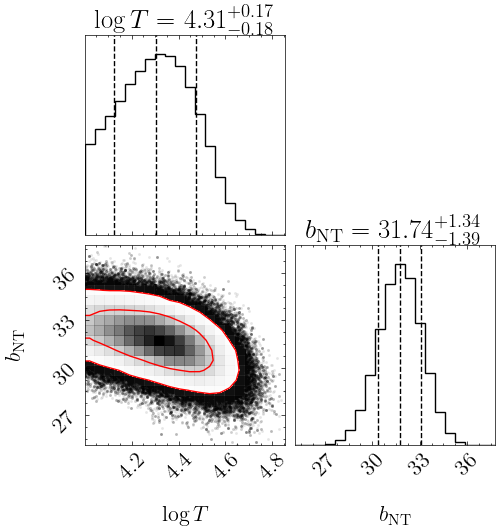

In [85]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [87]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.001273740172994, 4.717338946663806)

### c1L

In [89]:
b_list = [[
          ['OIV', 'O', 30, 2],
          ['OVI', 'O', 32, 3]
          ]]

In [90]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [91]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [92]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:10<00:00, 486.91it/s]


State([[ 5.94251348  6.70811439]
 [ 5.73749387 20.08477207]
 [ 5.07238633 30.74369963]
 [ 5.64421224 21.7330925 ]
 [ 5.75420391 15.31518387]
 [ 5.66397777 17.65148594]
 [ 5.87180993 17.28181557]
 [ 5.95051613  4.14909517]
 [ 5.75655966 21.51757216]
 [ 5.92051928  8.22421155]
 [ 5.85402471 12.73511637]
 [ 5.31025555 28.08377918]
 [ 5.81916552 11.45447804]
 [ 5.73780661 18.35447651]
 [ 5.86964452 11.2211438 ]
 [ 5.95903342  1.75886357]
 [ 5.49818637 23.76392989]
 [ 5.95753885  6.85583027]
 [ 5.31584703 26.75103642]
 [ 5.96121743  2.28679745]
 [ 5.83682026 13.73030731]
 [ 5.97608357  5.5361576 ]
 [ 5.94040563  0.13049163]
 [ 5.96441464  5.00504744]
 [ 5.42524587 27.04998453]
 [ 5.57944624 23.44890992]
 [ 5.58654632 23.19033414]
 [ 5.61809289 25.43911098]
 [ 5.52547367 23.34034939]
 [ 5.89555098 11.8134523 ]
 [ 5.77133038 15.89333101]
 [ 5.93530074 12.23585386]
 [ 5.24272343 30.13703054]
 [ 5.49590337 27.58180537]
 [ 5.39763307 28.41919845]
 [ 5.77105125 16.50771114]
 [ 5.64339271 21.41347

In [93]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

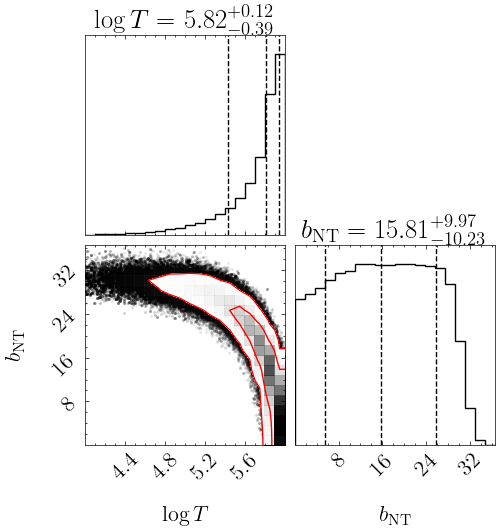

In [94]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

(array([ 49952.,  57591.,  60646.,  67264.,  74342.,  86246., 105169.,
        141928., 156070., 100792.]),
 array([ 10007.34549087, 109005.99128484, 208004.6370788 , 307003.28287277,
        406001.92866674, 505000.5744607 , 603999.22025467, 702997.86604864,
        801996.51184261, 900995.15763657, 999993.80343054]),
 <BarContainer object of 10 artists>)

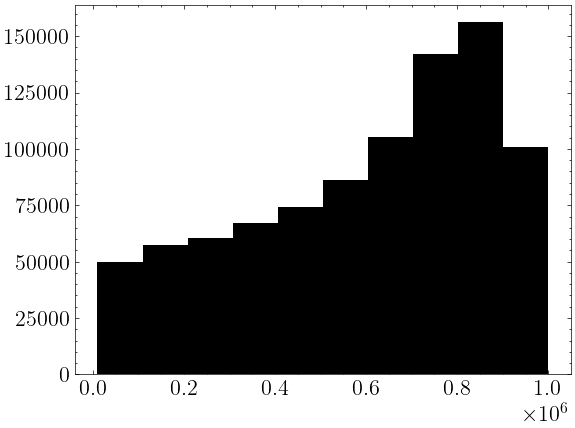

In [95]:
plt.hist(10**flat_samples['logT'])

In [96]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.106179215494935, 5.99921294236529)

In [97]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

33.207299962440004

# z=1.04

## c1

In [98]:
b_list = [[['HI', 'H', 19, 1],
           ['CIII', 'C', 6.8, 0.2],
           ['CIV', 'C', 6.8, 0.2],
           ['NIV', 'N', 6.8, 0.2],
           ['OIII', 'O', 6.8, 0.2],
           ['OIV', 'O', 6.8, 0.2],
           ]]

In [99]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [100]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [101]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:18<00:00, 265.44it/s]


State([[4.23780085 5.17412905]
 [4.36312297 4.24278005]
 [4.2687778  5.23523314]
 [4.32535061 4.57884159]
 [4.25587301 4.88095838]
 [4.17989479 5.48569748]
 [4.26529067 4.89153264]
 [4.33874157 4.45366425]
 [4.21794684 5.28919253]
 [4.28700264 4.81661747]
 [4.23713831 4.78201871]
 [4.21774305 5.1200313 ]
 [4.23268948 4.97438427]
 [4.24065258 5.02765337]
 [4.30945909 5.0717263 ]
 [4.26753365 4.94383706]
 [4.2992081  4.76405768]
 [4.22687804 4.97461013]
 [4.34665585 4.37451064]
 [4.2850065  5.01755784]
 [4.26886124 4.79975589]
 [4.28414946 4.76582617]
 [4.34707473 4.43295517]
 [4.1893218  5.0841976 ]
 [4.32167273 4.66184154]
 [4.2726825  4.90513348]
 [4.26616392 4.98920353]
 [4.31336163 4.4808809 ]
 [4.29006774 4.93700262]
 [4.31998453 4.5179484 ]
 [4.29453702 4.64527067]
 [4.2509585  5.01929279]
 [4.33826601 4.28829926]
 [4.36282163 4.39612238]
 [4.25586235 4.7247267 ]
 [4.36438589 4.26392395]
 [4.24582589 4.96748519]
 [4.26725829 4.9163401 ]
 [4.2492203  5.06172569]
 [4.29498719 4.8132

In [102]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

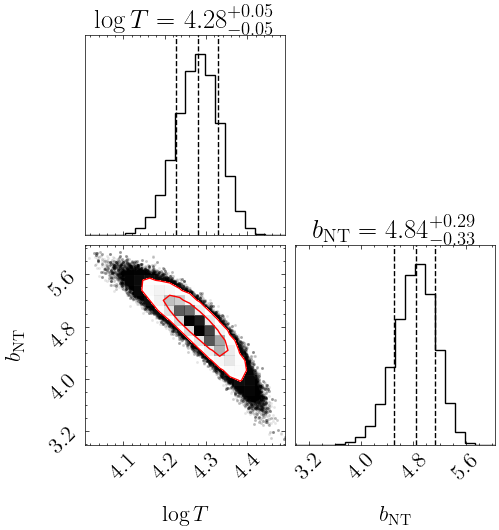

In [103]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [105]:
np.percentile(flat_samples['logT'],100*(1-cdf_3sig)), np.percentile(flat_samples['logT'],100*cdf_3sig)

(4.105551883395851, 4.421958342971334)

## c2

In [106]:
b_list = [[['HI', 'H', 10, 3],
           ['CIII', 'C', 6.1, 0.4],
           ['CIV', 'C', 6.1, 0.4],
           ['NIV', 'N', 6.1, 0.4],
           ['OIII', 'O', 6.1, 0.4],
           ['OIV', 'O', 6.1, 0.4],
           ]]

In [107]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [108]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [109]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:17<00:00, 280.80it/s]


State([[4.05775538 4.86820067]
 [4.00479369 4.83037758]
 [4.02006755 4.96030023]
 [4.06183869 4.94733229]
 [4.13169094 4.8654068 ]
 [4.05186826 4.43760983]
 [4.14280081 4.53626828]
 [4.05735587 4.80493461]
 [4.29282592 3.52723496]
 [4.08090406 4.87441855]
 [4.08582031 5.16967442]
 [4.10955432 4.82579227]
 [4.16006732 4.69153363]
 [4.0808996  4.8621759 ]
 [4.00959779 4.97509506]
 [4.24635807 3.84310445]
 [4.08083422 4.63819878]
 [4.08579345 4.47647215]
 [4.16957197 4.22971009]
 [4.09794823 4.45384011]
 [4.12719896 4.63292229]
 [4.06727864 4.90431365]
 [4.04448499 5.09932448]
 [4.00270644 4.87676629]
 [4.06972181 4.70566069]
 [4.00219458 4.99793648]
 [4.21284808 4.00097065]
 [4.18007405 4.23279791]
 [4.05392748 4.72347115]
 [4.15195346 4.5654666 ]
 [4.01201065 4.7023488 ]
 [4.18406804 4.65857829]
 [4.03685419 4.81311937]
 [4.21179297 3.69207072]
 [4.01771101 5.23069485]
 [4.22400005 3.94354791]
 [4.1115693  4.82603475]
 [4.10502383 4.88699858]
 [4.06868022 4.3524223 ]
 [4.04113762 4.9700

In [110]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

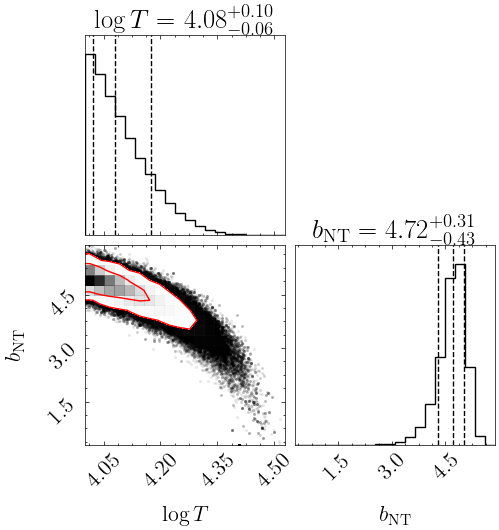

In [111]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [112]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.404080112661511

## c3

### c3H

In [128]:
b_list = [[['HI', 'H', 14, 4],
           ['NIV', 'C', 10, 1],
           ['CIII', 'C', 10, 1],
          ['CIV', 'C', 10, 1]]]

In [129]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [130]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [131]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:14<00:00, 335.66it/s]


State([[ 4.25283166  9.25402713]
 [ 4.1808572   8.65308285]
 [ 4.03711749  9.58009355]
 [ 4.2269516   7.5739051 ]
 [ 4.19809065  8.1941094 ]
 [ 4.06517119  9.57047743]
 [ 4.22075759  8.30459089]
 [ 4.24579921  8.89989312]
 [ 4.48583203  8.6319543 ]
 [ 4.14459152  9.01905879]
 [ 4.02815328  8.62094842]
 [ 4.16256778  9.07079203]
 [ 4.16313712  9.27190161]
 [ 4.07458039  9.6582971 ]
 [ 4.3951965   8.52820358]
 [ 4.37347908  7.56808647]
 [ 4.0906048   8.77648227]
 [ 4.01581464  9.26755209]
 [ 4.03088014  9.03219904]
 [ 4.24039117  8.43234457]
 [ 4.15103306  8.64236466]
 [ 4.02631799  8.82435105]
 [ 4.14473409  9.36817127]
 [ 4.21089744  8.65507422]
 [ 4.29106907  8.9996401 ]
 [ 4.39074601  7.04952282]
 [ 4.13982752  9.22520113]
 [ 4.05565509  9.09906371]
 [ 4.10505125  9.30801243]
 [ 4.24449214  8.28432558]
 [ 4.18187924  8.9229793 ]
 [ 4.21035672  9.21199643]
 [ 4.3854971   8.54206052]
 [ 4.25263761  8.81211834]
 [ 4.07721657  9.39062461]
 [ 4.33644092  9.51994041]
 [ 4.00915386  9.74963

In [132]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

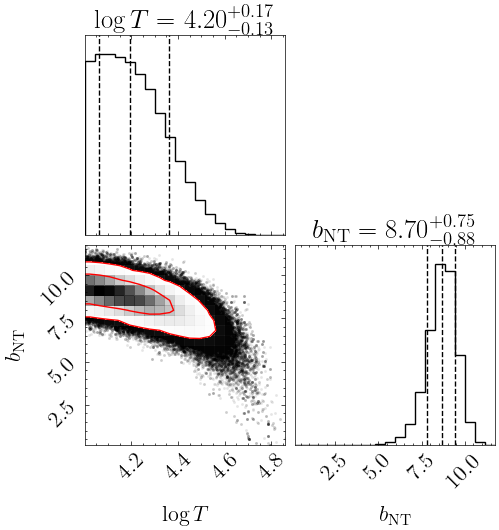

In [133]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [134]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.673579856451672

### c3L

In [120]:
b_list = [[['OIV', 'O', 10, 1]]]

In [121]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [122]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [123]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:08<00:00, 571.28it/s]


State([[ 5.0621491   1.03143619]
 [ 4.28942595  8.92232637]
 [ 5.04808904  2.50606955]
 [ 5.12647643  3.26353802]
 [ 4.76864145  3.4752566 ]
 [ 5.02530324  3.12552908]
 [ 4.68266064  8.11622072]
 [ 5.00369214  2.77040731]
 [ 5.05911568  1.21229475]
 [ 4.99903953  1.15549703]
 [ 4.23724933  9.00966049]
 [ 4.61546228  7.46920363]
 [ 4.89366143  5.92379643]
 [ 4.9829899   2.09384216]
 [ 4.81854839  2.28870051]
 [ 4.8566004   6.80830131]
 [ 4.92669987  4.93521142]
 [ 4.84984437  3.73676942]
 [ 4.43545723  9.44207658]
 [ 5.03778456  2.65645329]
 [ 4.91996991  2.58299309]
 [ 4.80892059  3.27033123]
 [ 4.58625319  5.69251397]
 [ 4.96034824  2.0756258 ]
 [ 4.89158678  5.24749422]
 [ 4.72667554  5.19222652]
 [ 4.63235206  7.25532452]
 [ 5.08729394  1.03184889]
 [ 4.8387693   5.99355215]
 [ 4.98902786  3.16428264]
 [ 4.56213825  6.76105398]
 [ 4.98943036  2.10496256]
 [ 4.95844117  3.10227364]
 [ 5.06582604  5.0617765 ]
 [ 5.03136413  0.50766732]
 [ 4.18057655  9.59877153]
 [ 4.56138159  8.26649

In [124]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

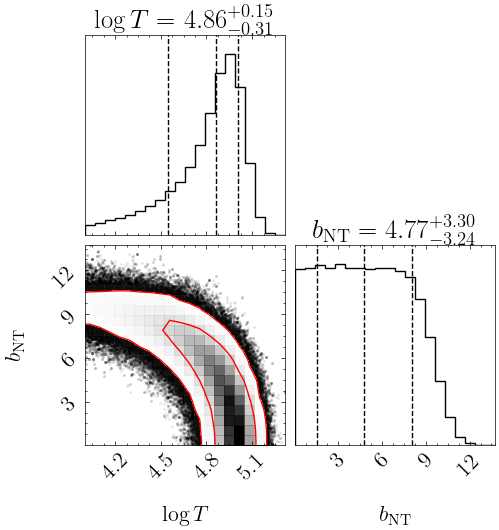

In [125]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [126]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

5.188689140833376

In [127]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

11.529533380669857

## c4

### c4H

In [64]:
b_list = [[['HI', 'H', 22, 5],
          ['OIII', 'O', 8.2, 0.6]]]

In [65]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [66]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [67]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:10<00:00, 491.11it/s]


State([[4.58209708 4.37301236]
 [4.40457895 8.31758063]
 [4.69554487 0.03824532]
 [4.74934693 3.62122599]
 [4.57533771 4.8954471 ]
 [4.77955726 0.46684817]
 [4.51072165 5.37094087]
 [4.4906288  4.99240288]
 [4.46937273 5.22991042]
 [4.49959947 6.61623362]
 [4.65781177 5.38177453]
 [4.68836843 4.5197735 ]
 [4.50599812 3.91934248]
 [4.17823161 6.85068968]
 [4.68659259 4.34826376]
 [4.50128095 5.38424449]
 [4.65880605 5.23227918]
 [4.62581721 4.12772856]
 [4.73555179 3.26251683]
 [4.43116971 6.4291395 ]
 [4.76869327 2.43832185]
 [4.63518714 5.76866206]
 [4.77854232 3.95449005]
 [4.79130815 2.29291721]
 [4.25263452 5.85609415]
 [4.44571513 6.32165129]
 [4.55535556 4.03787564]
 [4.37098346 6.53737804]
 [4.54429644 6.10162472]
 [4.66613278 3.90238881]
 [4.65175397 5.58467364]
 [4.46897035 4.79790665]
 [4.30465045 6.99260703]
 [4.38119749 5.25068103]
 [4.30889159 6.75688183]
 [4.5886762  5.17602829]
 [4.74159276 3.59037876]
 [4.47706308 5.03116049]
 [4.68519941 3.52819679]
 [4.63238885 5.4032

In [68]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

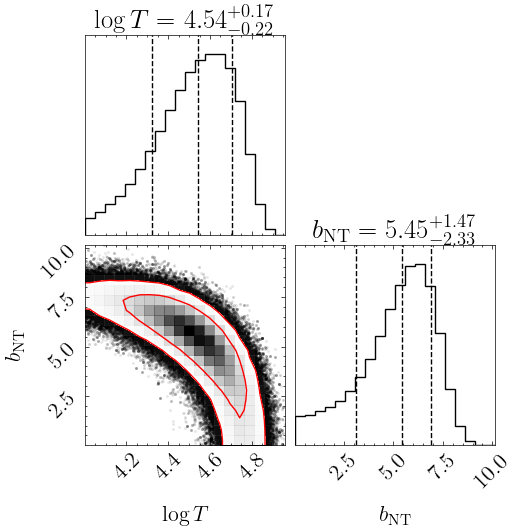

In [69]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [70]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

8.82846225112439

In [71]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.882888299305928

### c4L

In [72]:
b_list = [[['OIV', 'O', 8.2, 0.6],
           ['NIV', 'N', 8.2, 0.6],
           ['CIV', 'C', 8.2, 0.6],
           ['CIII', 'C', 8.2, 0.6]]]

In [73]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [74]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [75]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 379.44it/s]


State([[4.67918486 2.60077927]
 [4.23251584 6.24147153]
 [4.09275922 7.87314313]
 [4.12404075 7.48002605]
 [4.60273008 3.28719022]
 [4.75983457 1.96172109]
 [4.63878247 3.21836929]
 [4.41439426 5.33525971]
 [4.20869725 6.84782934]
 [4.73626675 2.03913821]
 [4.64550525 4.27621366]
 [4.64587623 3.74386381]
 [4.38432144 6.17747509]
 [4.58486392 4.12925185]
 [4.45703097 5.26191735]
 [4.36513885 5.34358394]
 [4.01447786 7.77523615]
 [4.66603481 3.29007928]
 [4.73694426 0.19339415]
 [4.58687836 3.43499479]
 [4.60092945 3.77030342]
 [4.5760965  4.54838376]
 [4.50040018 4.7454615 ]
 [4.73005256 0.07937709]
 [4.51455567 4.63891799]
 [4.3942181  5.52153235]
 [4.31652804 6.44544738]
 [4.37723579 6.21555551]
 [4.45081225 5.24132121]
 [4.46696577 4.36230527]
 [4.22722382 6.44526811]
 [4.42089197 5.59364361]
 [4.21047578 7.19356544]
 [4.0600545  7.59343315]
 [4.78017241 2.80684871]
 [4.6569976  2.85992564]
 [4.58017045 4.58724506]
 [4.71273169 1.83945624]
 [4.60273071 4.45702881]
 [4.39085952 5.9505

In [76]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

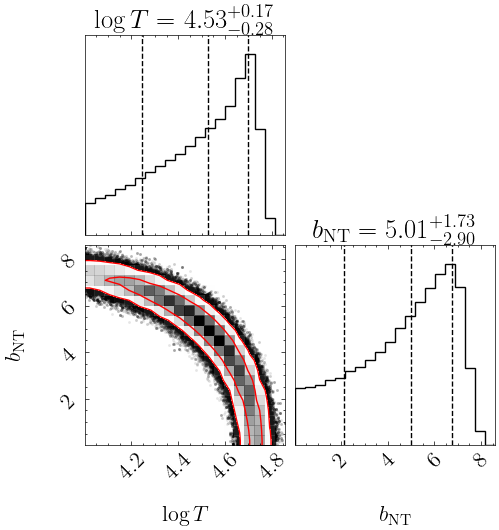

In [77]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [78]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

7.987508696920045

In [79]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.798602874991483

# z=1.09

## c1

### c1L

In [135]:
b_list = [[['HI', 'H', 21, 3],
           ['CIII', 'C', 18.3, 0.3],
          ['CIV', 'C', 18.3, 0.3],
          ['NIV', 'N', 13, 6]]]

In [136]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [137]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [138]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:14<00:00, 352.09it/s]


State([[ 4.31484459 17.45677352]
 [ 4.39456499 17.78356044]
 [ 4.20776542 18.16456255]
 [ 4.3894518  17.35456713]
 [ 4.26058838 17.67889382]
 [ 4.24627005 17.35120902]
 [ 4.31395144 17.28481125]
 [ 4.26387933 17.79595787]
 [ 4.58760569 16.85892513]
 [ 4.33419631 17.76747402]
 [ 4.27305813 17.87587607]
 [ 4.42441566 17.3476392 ]
 [ 4.28684151 17.47846135]
 [ 4.18186178 17.70587204]
 [ 4.0335425  17.336123  ]
 [ 4.120461   17.80770573]
 [ 4.1838004  17.60515488]
 [ 4.3102085  17.41549852]
 [ 4.2334268  17.74074868]
 [ 4.15445628 17.61272623]
 [ 4.24929297 17.75858532]
 [ 4.05342147 17.87819081]
 [ 4.03018759 17.44774387]
 [ 4.20059763 17.48531159]
 [ 4.07012299 17.7587353 ]
 [ 4.0931838  17.84729483]
 [ 4.06930856 17.74026496]
 [ 4.38054504 17.27211627]
 [ 4.15596484 17.8360368 ]
 [ 4.24104524 17.39433194]
 [ 4.165567   17.63282779]
 [ 4.18067082 17.70195109]
 [ 4.02495677 17.44896402]
 [ 4.37895798 17.58424095]
 [ 4.24556478 17.3336616 ]
 [ 4.11520678 18.26124614]
 [ 4.40319123 17.58951

In [139]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

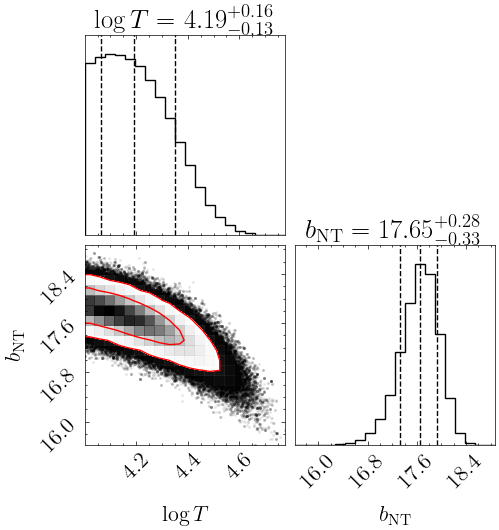

In [140]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [141]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.629395533831149

### c1H

In [23]:
b_list = [[['OIV', 'O', 23, 1],
          ['OV', 'O', 26, 2]]]

In [24]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [25]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [26]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:10<00:00, 475.04it/s]


State([[5.65606221e+00 7.47392611e+00]
 [5.67742762e+00 4.95257119e+00]
 [5.75121153e+00 7.76777108e-03]
 [5.73056423e+00 1.16512109e+00]
 [5.69044780e+00 5.17732125e-01]
 [5.73021489e+00 4.82802200e+00]
 [5.76507719e+00 1.14714729e+00]
 [5.51964287e+00 1.51609092e+01]
 [5.28087283e+00 1.80558836e+01]
 [5.66555660e+00 5.46679246e+00]
 [5.34732572e+00 2.02473976e+01]
 [5.40786448e+00 1.64786444e+01]
 [5.72214491e+00 1.03249679e+00]
 [5.75260780e+00 1.52309630e+00]
 [5.35912585e+00 1.93668869e+01]
 [5.67655145e+00 1.02130014e+01]
 [5.64278147e+00 1.10340128e+01]
 [5.64333481e+00 8.70845948e+00]
 [5.11061186e+00 1.88801545e+01]
 [5.04639610e+00 2.06930034e+01]
 [5.72435485e+00 5.29589067e+00]
 [5.73939214e+00 2.16883706e+00]
 [5.64575188e+00 7.18153694e+00]
 [5.72137777e+00 4.60026649e+00]
 [5.18325911e+00 2.09137044e+01]
 [5.65513798e+00 8.84672871e+00]
 [5.52472911e+00 1.29963419e+01]
 [5.40224001e+00 1.43478648e+01]
 [5.45288250e+00 1.62936233e+01]
 [5.46287992e+00 1.50551574e+01]
 [4.

In [27]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

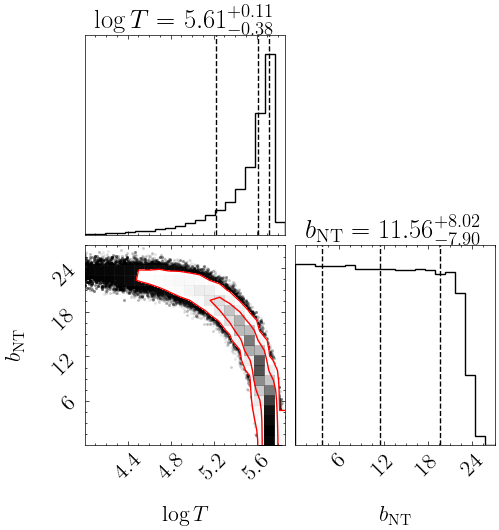

In [28]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [29]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.057505343991724, 5.806226549590672)

In [30]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

24.674661574899364

# z=1.16

## c1

In [142]:
b_list = [[['HI', 'H', 19, 3],
          ['HeI', 'He', 12, 1],
          ['CIII', 'C', 11.0, 0.4],
          ['CIV', 'C', 11.0, 0.4],
          ['OIII', 'O', 14, 3],
          ['OIV', 'O', 16, 2],
          ['OV', 'O', 10, 3],
          ['SiIII', 'Si', 11, 2]]]

In [143]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [144]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [145]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:22<00:00, 224.63it/s]


State([[ 4.04573726 10.24874863]
 [ 4.27665383  9.24875061]
 [ 4.31274657  9.08234595]
 [ 4.37081949  9.57408706]
 [ 4.08999127 10.06247661]
 [ 4.26426483  9.56353781]
 [ 4.36118227  9.74047865]
 [ 4.2675164   9.82293473]
 [ 4.06418037 11.13232762]
 [ 4.0979543  10.14238869]
 [ 4.14362686 10.10014236]
 [ 4.18016118 10.11291211]
 [ 4.11201107  9.93771341]
 [ 4.24177291  9.34099215]
 [ 4.03410565 10.57636267]
 [ 4.14308718  9.99676785]
 [ 4.07297676 10.40452732]
 [ 4.10542633 10.50788997]
 [ 4.07722525 10.61904741]
 [ 4.25743807 10.04426494]
 [ 4.23573487  9.83830455]
 [ 4.26436848  9.60916551]
 [ 4.28672171 10.25303677]
 [ 4.23055559 10.14048203]
 [ 4.1149614  10.37610384]
 [ 4.20637993  9.81992527]
 [ 4.1747124   9.99461825]
 [ 4.10338328 10.24952412]
 [ 4.24253792  9.89756819]
 [ 4.26888788  9.56918895]
 [ 4.22894843  9.83806474]
 [ 4.18370997  9.88990324]
 [ 4.10712863 11.40380146]
 [ 4.26859311 10.02773127]
 [ 4.26582546  9.80197475]
 [ 4.03352491 10.54015537]
 [ 4.2358743   9.62780

In [146]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

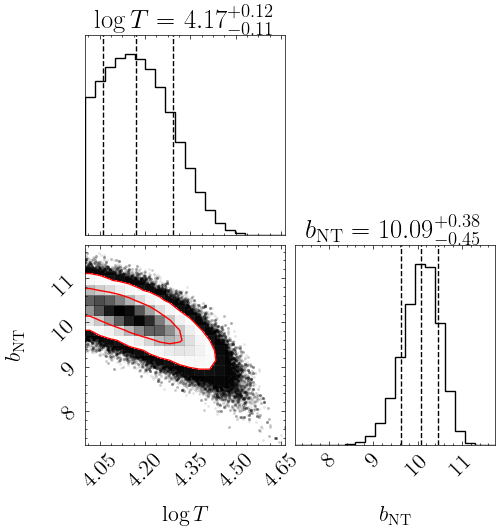

In [147]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [148]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.50567927331948

## c2

### Single phase

In [218]:
b_list = [[['HI', 'H', 32, 3],
           ['CIV', 'C', 27, 3],
          ['OIV', 'O', 27, 7],
          ['OV', 'O', 28, 3]]]

In [219]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [220]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [221]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:14<00:00, 341.57it/s]


State([[ 4.53465668 25.98522665]
 [ 4.6095332  24.65527858]
 [ 4.56822327 27.03525205]
 [ 4.25491889 26.65317736]
 [ 4.53794817 25.30200484]
 [ 4.40445216 27.73959309]
 [ 4.04013213 29.04633956]
 [ 4.53557986 26.19748162]
 [ 4.05640921 23.56665944]
 [ 4.36634781 26.64931093]
 [ 4.39646132 28.78526567]
 [ 4.29641575 27.74594063]
 [ 4.18764095 28.69039776]
 [ 4.43869842 27.06319603]
 [ 4.07493775 31.50913016]
 [ 4.22458264 24.54326565]
 [ 4.73755521 23.45134685]
 [ 4.23281599 25.21228323]
 [ 4.20019477 23.16973728]
 [ 4.06732283 27.35189962]
 [ 4.58543038 24.36001244]
 [ 4.52018318 23.69032684]
 [ 4.12367147 25.20681568]
 [ 4.17914925 26.04415854]
 [ 4.34791798 25.79894429]
 [ 4.42056695 26.3323048 ]
 [ 4.41677005 24.58719158]
 [ 4.11486026 29.10688129]
 [ 4.5212596  26.13995661]
 [ 4.3767721  27.50792398]
 [ 4.54497262 28.16254816]
 [ 4.05698554 30.27542053]
 [ 4.21494021 29.58890945]
 [ 4.22290639 27.50416318]
 [ 4.42992578 27.88114032]
 [ 4.18319958 27.85225699]
 [ 4.1473791  27.20835

In [222]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

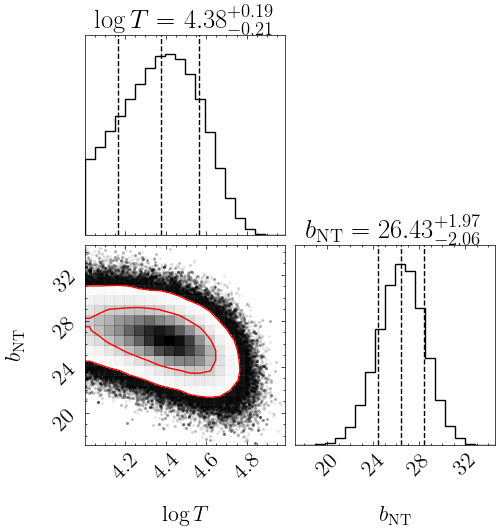

In [223]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [224]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.8310339336921295, 32.222309418822626)

### c2H

In [149]:
b_list = [[['HI', 'H', 32, 3]]]
          #['OVI', 'O', 45, 22]]]

In [150]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [151]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [152]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:08<00:00, 577.51it/s]


State([[4.72434479e+00 2.16012030e+01]
 [4.90537030e+00 5.14174604e+00]
 [4.26575200e+00 3.59159362e+01]
 [4.69348433e+00 7.42587512e+00]
 [4.50514999e+00 1.95401399e+01]
 [4.45041453e+00 2.37347965e+01]
 [4.64190527e+00 2.05662733e+01]
 [4.39055019e+00 2.19512687e+01]
 [4.93768379e+00 1.05773499e+01]
 [4.67810690e+00 1.63505614e+01]
 [4.37439332e+00 2.57386400e+01]
 [4.35076097e+00 2.52279848e+01]
 [4.60713777e+00 1.93993831e+01]
 [4.72215673e+00 3.21147155e-01]
 [4.42819198e+00 2.94082597e+01]
 [4.61088107e+00 2.00409554e+01]
 [4.75502415e+00 6.83743203e+00]
 [4.66177411e+00 1.31990218e+01]
 [4.79662171e+00 9.49963712e-01]
 [4.72220006e+00 1.46330141e+01]
 [4.19666860e+00 2.82859551e+01]
 [4.77906313e+00 9.15610862e+00]
 [4.85359186e+00 1.73166776e+00]
 [4.50262159e+00 2.32715836e+01]
 [4.55408900e+00 2.33753330e+01]
 [4.69324328e+00 1.86994331e+01]
 [4.19386671e+00 2.74580265e+01]
 [4.81431595e+00 1.03947512e+01]
 [4.82755443e+00 1.08055098e+00]
 [4.56270602e+00 1.85965619e+01]
 [4.

In [153]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

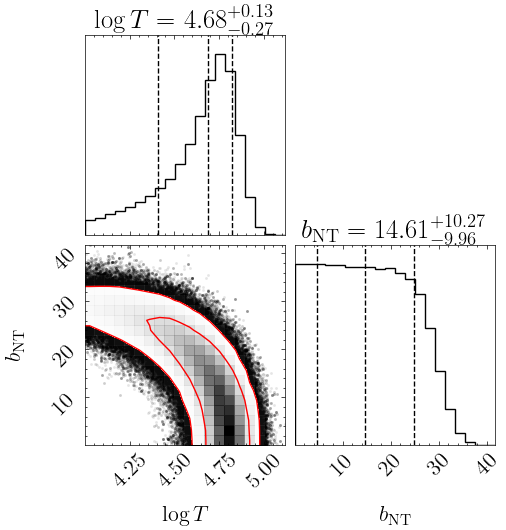

In [154]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [155]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.991130810017263, 35.63658755609632)

### c2L

In [156]:
b_list = [[['CIV', 'C', 27, 3],
          ['OIV', 'O', 27, 7],
          ['OV', 'O', 28, 3]]]
          #['OVI', 'O', 45, 22]]]

In [157]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [158]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [159]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 382.15it/s]


State([[ 5.56989745 21.25794638]
 [ 5.75606415  0.51512216]
 [ 5.17678089 26.33256245]
 [ 5.38884707 23.59498446]
 [ 4.57126217 24.00642127]
 [ 5.73023677 15.15182534]
 [ 5.35115273 19.45148542]
 [ 5.36983722 20.94759066]
 [ 4.80446633 27.13196937]
 [ 5.088083   23.52314542]
 [ 5.37151365 19.98495818]
 [ 5.4700434  17.74395005]
 [ 5.667975   13.55071241]
 [ 5.5662273  18.35110854]
 [ 5.79366909 16.62221644]
 [ 5.7702386   0.46083088]
 [ 5.70662396 12.26329128]
 [ 5.53021431 13.28011984]
 [ 5.31776909 20.36517947]
 [ 5.13189227 25.29487667]
 [ 5.4078951  19.24791307]
 [ 4.33426117 26.97317781]
 [ 5.67776271  0.70465928]
 [ 5.39686797 20.24837763]
 [ 5.70385154  5.36771573]
 [ 5.7430824   5.81969348]
 [ 5.71063049 15.23345097]
 [ 5.71711181 15.02654829]
 [ 5.69409868  6.10397968]
 [ 5.47163287 25.86097387]
 [ 5.71889961  5.87018715]
 [ 5.62870805 18.98518564]
 [ 5.77409795 20.61515687]
 [ 5.78830345  8.0694555 ]
 [ 5.27767601 23.97178467]
 [ 5.48207224 24.30627658]
 [ 5.76417891 13.57822

In [160]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

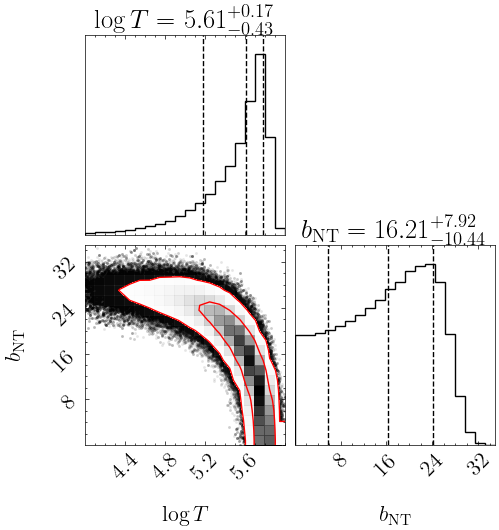

In [161]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [163]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(5.9417088094470065, 31.07864996544844)

# z=1.22

## c1

### Single phase

In [225]:
b_list = [[['HI', 'H', 26, 5],
           ['CIV', 'C', 16, 3],
          ['OIV', 'O', 21, 2],
          ['OV', 'O', 21, 2],
          ['OVI', 'O', 21, 2]]]

In [226]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [227]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [228]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:16<00:00, 303.36it/s]


State([[ 4.74732971 17.51137248]
 [ 4.78204427 17.37384357]
 [ 4.57550512 18.71977755]
 [ 4.23700535 19.19144468]
 [ 4.59488354 19.58142216]
 [ 4.63715557 18.23654804]
 [ 4.22229816 17.90775123]
 [ 4.63784625 19.11917179]
 [ 4.82898493 18.82275018]
 [ 4.57623282 18.29372517]
 [ 4.52950277 18.07579568]
 [ 4.64198616 19.2812896 ]
 [ 4.26462105 20.71321431]
 [ 4.44088053 21.12907461]
 [ 4.69543865 16.61876565]
 [ 4.35892068 19.21986564]
 [ 4.8333941  19.49534308]
 [ 4.23013873 21.76928349]
 [ 4.05048898 20.18513632]
 [ 4.06741821 19.56873061]
 [ 4.55539515 18.70925759]
 [ 4.1455667  17.88635729]
 [ 4.16826767 19.49708928]
 [ 4.49804517 16.60617824]
 [ 4.30708748 19.74828054]
 [ 4.31943011 19.798762  ]
 [ 4.19165328 20.8218256 ]
 [ 4.73303318 19.01431263]
 [ 4.37198643 19.58382216]
 [ 4.49341827 20.55612338]
 [ 4.10113339 21.44956401]
 [ 4.87632154 17.01481007]
 [ 4.36196072 18.71576728]
 [ 4.21841117 17.94697738]
 [ 4.2609033  21.18364011]
 [ 4.39639771 19.23352808]
 [ 4.56664762 18.62615

In [229]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

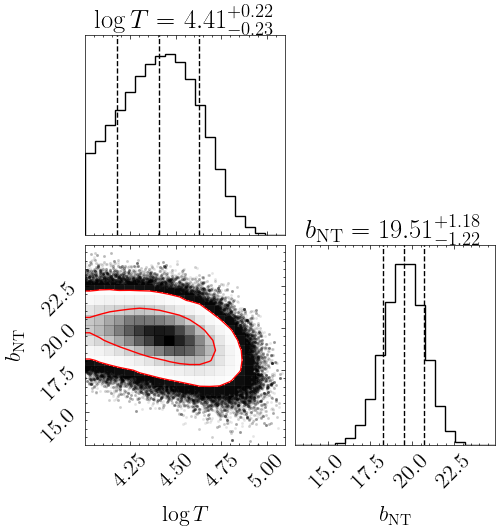

In [230]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [231]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.944070346230868, 22.983617631470345)

### c1H

In [164]:
b_list = [[['HI', 'H', 26, 5]]]

In [165]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [166]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [167]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:08<00:00, 593.53it/s]


State([[ 4.44435753 22.75388529]
 [ 4.59545573 13.46764563]
 [ 4.73176621  4.0570611 ]
 [ 4.63223791  1.38047967]
 [ 4.27665238  9.73879685]
 [ 4.50477232 18.00188666]
 [ 4.01788802 25.20552431]
 [ 4.38993338  6.05955953]
 [ 4.41004512 33.1461769 ]
 [ 4.71553583  5.47294377]
 [ 4.68741447  7.05537041]
 [ 4.48544124 13.50827735]
 [ 4.63561502 10.75198555]
 [ 4.80561193 20.1749136 ]
 [ 4.115426   13.05647061]
 [ 4.56072522  2.87852525]
 [ 4.81360544  6.30700259]
 [ 4.57336111  9.73501689]
 [ 4.49622858 14.93670621]
 [ 4.29735743 17.05154447]
 [ 4.64782447  5.35326265]
 [ 4.70558395  2.41004745]
 [ 4.09885369 21.00886242]
 [ 4.62510424  1.12490922]
 [ 4.57222852 11.9182345 ]
 [ 4.23186972 11.7205246 ]
 [ 4.33507286 13.13114601]
 [ 4.44858087 24.39518649]
 [ 4.69534605  5.23501289]
 [ 4.38710283 18.09268258]
 [ 4.12514257 24.70728003]
 [ 4.46983132 19.52528509]
 [ 5.02453157  0.46991095]
 [ 4.77034982  4.48197777]
 [ 4.259421   20.92928926]
 [ 4.15013259 27.19399878]
 [ 4.79550367  1.35010

In [168]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

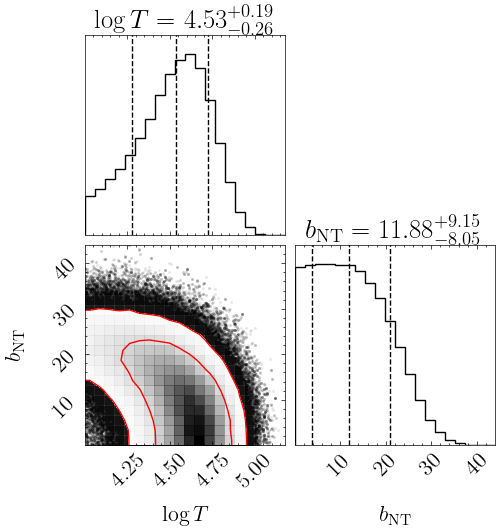

In [169]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [171]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(4.998429284984908, 35.2476957469246)

### c1L

In [172]:
b_list = [[['CIV', 'C', 16, 3],
          ['OIV', 'O', 21, 2],
          ['OV', 'O', 21, 2],
          ['OVI', 'O', 21, 2]]]

In [173]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [174]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [175]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:15<00:00, 324.21it/s]


State([[4.79071254e+00 1.88150352e+01]
 [5.02887847e+00 1.77695527e+01]
 [5.52090329e+00 9.34419995e+00]
 [5.37308035e+00 1.27275409e+01]
 [4.61252974e+00 1.95090401e+01]
 [5.43971996e+00 1.25368837e+01]
 [5.56516863e+00 9.83619150e-01]
 [5.46284302e+00 8.21054934e+00]
 [5.39636384e+00 1.39243187e+01]
 [5.50562777e+00 1.05863252e+01]
 [4.08578193e+00 1.99265392e+01]
 [5.04376412e+00 1.46481910e+01]
 [5.59097075e+00 3.42316470e+00]
 [4.74595205e+00 1.75779922e+01]
 [4.12940306e+00 2.04996601e+01]
 [5.12037089e+00 1.46905465e+01]
 [4.84943909e+00 1.80205454e+01]
 [5.09353491e+00 1.60439083e+01]
 [5.40121414e+00 1.21299761e+01]
 [5.57965546e+00 7.02197347e+00]
 [5.42369851e+00 1.26587549e+01]
 [5.10618183e+00 1.63430698e+01]
 [4.49007278e+00 1.99251536e+01]
 [5.02068120e+00 1.79520127e+01]
 [5.28310220e+00 1.71938629e+01]
 [4.78583067e+00 1.85412265e+01]
 [4.72031606e+00 2.03626057e+01]
 [5.46309937e+00 1.22340619e+01]
 [5.09617739e+00 1.78893010e+01]
 [5.29627453e+00 1.19694948e+01]
 [4.

In [176]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

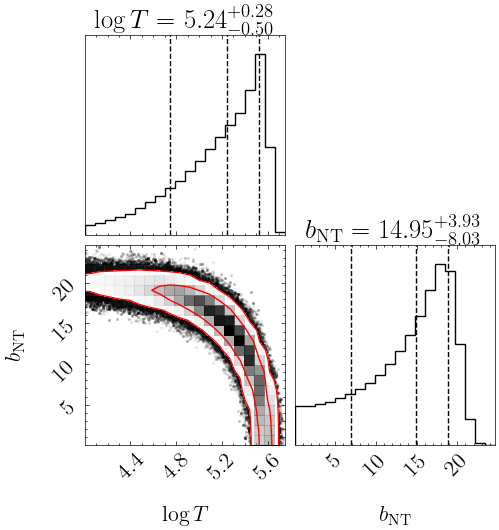

In [177]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [178]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(5.673779496232167, 22.30335617117136)

# z=1.26

## c1

In [179]:
b_list = [[['HI', 'H', 22, 2],
           ['CIII', 'C', 6.6, 0.6],
          ['CIV', 'C', 6.6, 0.6],
           ['OIV', 'O', 6.6, 0.6]
          ]]

In [180]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [181]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [182]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:14<00:00, 340.00it/s]


State([[4.43234262 4.02255988]
 [4.61233431 0.34997963]
 [4.52230146 0.19310782]
 [4.53854687 1.18907829]
 [4.463935   2.7179154 ]
 [4.4831235  2.97259435]
 [4.30498632 4.13820981]
 [4.47789977 3.15972602]
 [4.57484126 0.07402321]
 [4.46960567 2.76181206]
 [4.45422216 2.5569221 ]
 [4.3900722  3.49267751]
 [4.5533408  1.2682738 ]
 [4.5170028  0.58563087]
 [4.58916541 1.56961278]
 [4.5491696  0.88105888]
 [4.36891109 4.17597739]
 [4.50036764 1.17529187]
 [4.3637475  3.91653484]
 [4.48884695 2.23473914]
 [4.36937196 4.0065395 ]
 [4.36185489 3.88448916]
 [4.28010172 4.84566348]
 [4.51802406 1.92520175]
 [4.53756673 0.24856667]
 [4.49925647 1.82652896]
 [4.55601127 0.43307064]
 [4.46441924 3.87006707]
 [4.48820663 1.70661389]
 [4.4596269  3.8456898 ]
 [4.42768575 4.15214029]
 [4.42887631 1.96756283]
 [4.58797713 1.87488204]
 [4.49376951 3.19222236]
 [4.42154094 3.21406336]
 [4.51830081 1.70188869]
 [4.43771805 1.62785174]
 [4.43792832 2.46678967]
 [4.51194408 1.69442136]
 [4.35043868 2.4311

In [183]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

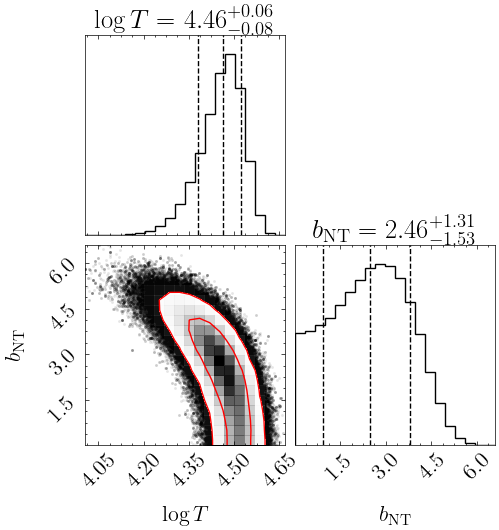

In [184]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [185]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.160023964088869, 4.610825415909572)

In [186]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

5.588354964903859

# z=1.27

## c1

### c1L

In [257]:
b_list = [[['HI', 'H', 24, 3],
          ['OIII', 'O', 11.9, 0.9]]]

In [258]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [259]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [260]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:10<00:00, 465.22it/s]


State([[ 4.62406875  9.79594406]
 [ 4.61307353  8.58439195]
 [ 4.22909536 11.93101429]
 [ 4.51777489 11.22039887]
 [ 4.52036704  9.99908363]
 [ 4.56335275 10.57480279]
 [ 4.43487739 10.90252947]
 [ 4.60154195 10.55802638]
 [ 4.54738669  8.22375018]
 [ 4.62172147  8.73670209]
 [ 4.43871046 10.64868021]
 [ 4.49599788  9.92307125]
 [ 4.58162754  9.75228291]
 [ 4.36357191 10.9697865 ]
 [ 4.65884655  9.53710342]
 [ 4.59341713 12.55070569]
 [ 4.47918401  8.85032642]
 [ 4.355355    8.86508757]
 [ 4.42031971 11.06741911]
 [ 4.4183998  10.71591582]
 [ 4.23866881 11.73492685]
 [ 4.03807147 12.13468212]
 [ 4.52917497 10.74512768]
 [ 4.41554742 11.68416582]
 [ 4.35814619 10.45800165]
 [ 4.52712165 10.23614099]
 [ 4.43317343  9.42547604]
 [ 4.45127276 11.81321359]
 [ 4.42309475 11.08862168]
 [ 4.59716111 10.821066  ]
 [ 4.68437462 10.36350268]
 [ 4.28024018  9.66430589]
 [ 4.46271482  8.35263904]
 [ 4.47921636 11.70098933]
 [ 4.54822702 10.97554643]
 [ 4.35742602  9.81555012]
 [ 4.46347295 10.49336

In [261]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

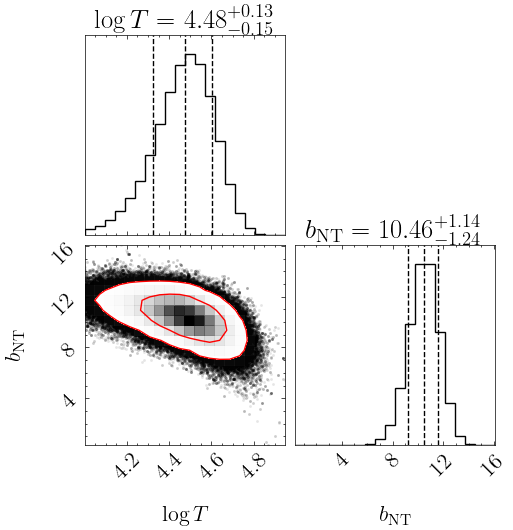

In [262]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [263]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.0155487782021595, 4.805663201201206)

### c1H

In [264]:
b_list = [[['CIII', 'C', 11.1, 0.2],
           ['CIV', 'C', 11.1, 0.2],
           ['NIV', 'N', 12, 6],
          ['OIV', 'O', 12, 1],
          ['OV', 'O', 17, 1],
          ['NeV', 'Ne', 21, 4]]]

In [265]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [266]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [267]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:17<00:00, 286.79it/s]


State([[ 4.48199151  9.1118659 ]
 [ 4.07921463 10.4358354 ]
 [ 4.41907496  9.38670711]
 [ 4.16604145 10.25625729]
 [ 4.00852313 10.53254479]
 [ 4.08555678 10.48148277]
 [ 4.23495003 10.16441424]
 [ 4.25430085 10.18208478]
 [ 4.18831335 10.22484797]
 [ 4.18222121 10.34363845]
 [ 4.19603991 10.01015133]
 [ 4.1773996  10.19444146]
 [ 4.10331908 10.3256178 ]
 [ 4.23931061  9.94398973]
 [ 4.27524703 10.07326355]
 [ 4.54995434  8.61282944]
 [ 4.38820929  9.4039619 ]
 [ 4.1882892  10.06322093]
 [ 4.08018744 10.49847602]
 [ 4.21114974 10.24889019]
 [ 4.19409807 10.1001928 ]
 [ 4.39871867  9.77254036]
 [ 4.16394325 10.39698784]
 [ 4.02352852 10.44909604]
 [ 4.19796379 10.31191536]
 [ 4.22568395 10.04420415]
 [ 4.19799685 10.14605496]
 [ 4.02137017 10.4784738 ]
 [ 4.27888404  9.90994223]
 [ 4.06378455 10.4157308 ]
 [ 4.08593224 10.6333646 ]
 [ 4.28262037 10.36567808]
 [ 4.37803689  9.43714535]
 [ 4.21771439 10.22705665]
 [ 4.39361948  9.61457087]
 [ 4.36167717  9.90295056]
 [ 4.05893987 10.42901

In [268]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

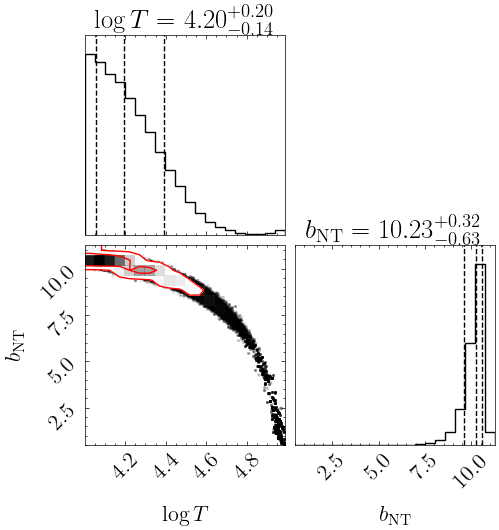

In [269]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [270]:
np.percentile(flat_samples['logT'], 100*(1-cdf_3sig)), np.percentile(flat_samples['logT'], 100*cdf_3sig)

(4.000452318706313, 4.9627813111881665)

In [271]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

10.934666174976197

## c2

### Single phase

In [232]:
b_list = [[['HI', 'H', 36, 10],
          ['CIV', 'C', 9.8, 0.3],
          ['OIV', 'O', 11, 2],
          ['OV', 'O', 15, 2],
          ['OVI', 'O', 15, 2],
          ['NeV', 'Ne', 17, 3]
          ]]

In [233]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [234]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [235]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:18<00:00, 267.60it/s]


State([[4.76800922 4.74866895]
 [4.52729432 7.37564673]
 [4.41822822 8.27163954]
 [4.46665492 8.26769125]
 [4.34413173 8.92311121]
 [4.67152145 6.47804436]
 [4.27021028 8.90085575]
 [4.3260319  8.24494925]
 [4.60173882 7.79204428]
 [4.46750235 7.30928421]
 [4.49490838 7.773431  ]
 [4.3901168  8.52359199]
 [4.80945303 3.36365757]
 [4.46217037 7.8446953 ]
 [4.8386095  1.09084986]
 [4.47646702 6.91897807]
 [4.17117396 9.71729133]
 [4.63711213 7.00997286]
 [4.36204621 8.71489166]
 [4.4498856  8.1069458 ]
 [4.40991572 8.00661292]
 [4.21112617 8.09280761]
 [4.43728269 8.46900997]
 [4.51237036 7.77600764]
 [4.55492589 7.38739352]
 [4.38588674 8.56076777]
 [4.26628425 8.82146038]
 [4.73472389 5.61029482]
 [4.33019338 8.20806771]
 [4.19251721 8.70620732]
 [4.00790572 9.15082572]
 [4.54157582 8.25072228]
 [4.51378703 7.11736444]
 [4.58893403 7.12396862]
 [4.69781342 6.7443369 ]
 [4.26791225 8.31762588]
 [4.416539   8.05104537]
 [4.44414511 7.53359061]
 [4.14094371 9.26859733]
 [4.38886657 8.2852

In [236]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

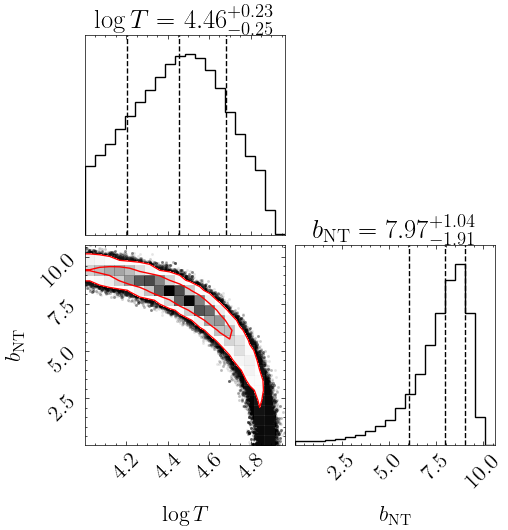

In [237]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [240]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.904343780447453

### c2H

In [248]:
b_list = [[['HI', 'H', 36, 10]
          ]]

In [249]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [250]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [251]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:07<00:00, 625.74it/s]


State([[ 5.25155637  2.3988417 ]
 [ 4.75059693 38.23391801]
 [ 4.42657562 27.4685133 ]
 [ 4.54664241 24.23791465]
 [ 4.95357774 39.24021353]
 [ 4.66201469 29.73696119]
 [ 4.72597876 11.44685617]
 [ 4.89548037 14.87793291]
 [ 4.05544758 11.34345911]
 [ 5.05176181 21.1889771 ]
 [ 4.78225227 10.52615259]
 [ 5.17655894  6.80684801]
 [ 4.79970335 12.42491382]
 [ 4.34350532 30.76642092]
 [ 4.3441447  15.53711651]
 [ 4.65881001  6.093149  ]
 [ 5.3944755  14.000961  ]
 [ 4.9804871  28.82456148]
 [ 4.93795249 21.75227421]
 [ 5.02419357 11.24366295]
 [ 4.93497774  7.02207249]
 [ 4.33213439 43.80379542]
 [ 4.648718   20.60658948]
 [ 4.18791517 19.32725891]
 [ 4.67238891 29.01266791]
 [ 4.50024483 26.40051258]
 [ 4.69409773 10.15455944]
 [ 4.88737646 39.56394574]
 [ 4.76185554 27.06448317]
 [ 4.73091632 14.70587876]
 [ 5.10150761 17.59367931]
 [ 4.15708005 11.80103099]
 [ 4.94020095  8.2677332 ]
 [ 4.20247665 36.91260786]
 [ 4.86177882 22.11869323]
 [ 4.7456456  27.37202559]
 [ 4.74500658 29.72506

In [252]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

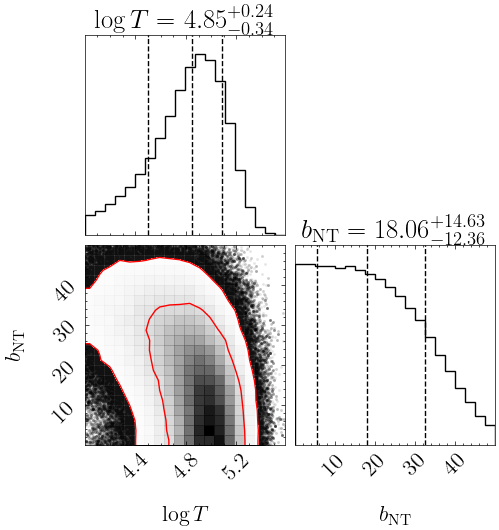

In [253]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [256]:
np.percentile(flat_samples['logT'], 100*cdf_3sig), np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

(5.424156425026777, 49.53383672033131)

### c2L

In [241]:
b_list = [[['CIV', 'C', 9.8, 0.3],
          ['OIV', 'O', 11, 2],
          ['OV', 'O', 15, 2],
          ['OVI', 'O', 15, 2],
          ['NeV', 'Ne', 17, 3]
          ]]

In [242]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [243]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [244]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:16<00:00, 301.88it/s]


State([[ 4.58669212  7.91195035]
 [ 4.46257542  8.3705068 ]
 [ 4.20162291  9.14134457]
 [ 4.46855533  7.74428012]
 [ 4.75142709  5.58594831]
 [ 4.27670285  8.91857837]
 [ 4.46765213  8.13586152]
 [ 4.129362    8.75384687]
 [ 4.83678989  3.71453144]
 [ 4.17722728  9.45800037]
 [ 4.32146399  8.43790865]
 [ 4.28816852  8.69072654]
 [ 4.38039465  8.17626458]
 [ 4.23813827  8.877668  ]
 [ 4.70544069  5.59597969]
 [ 4.61900373  7.63445843]
 [ 4.61225899  7.06752757]
 [ 4.00108975  9.11591628]
 [ 4.76218746  3.50615463]
 [ 4.26651446  8.50838233]
 [ 4.58004261  7.28871964]
 [ 4.54773622  7.75657526]
 [ 4.48942712  8.17972001]
 [ 4.09363373  9.89997544]
 [ 4.60158129  6.31778244]
 [ 4.35376352  8.63915272]
 [ 4.49291311  7.96811461]
 [ 4.83595476  1.94395553]
 [ 4.29740171  8.69928057]
 [ 4.20475719  9.05814926]
 [ 4.22510152  8.52420998]
 [ 4.01002778 10.27660513]
 [ 4.00742845  9.18881725]
 [ 4.52657541  7.12494807]
 [ 4.60363315  6.77931328]
 [ 4.35795846  8.64297006]
 [ 4.27615014  8.44400

In [245]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

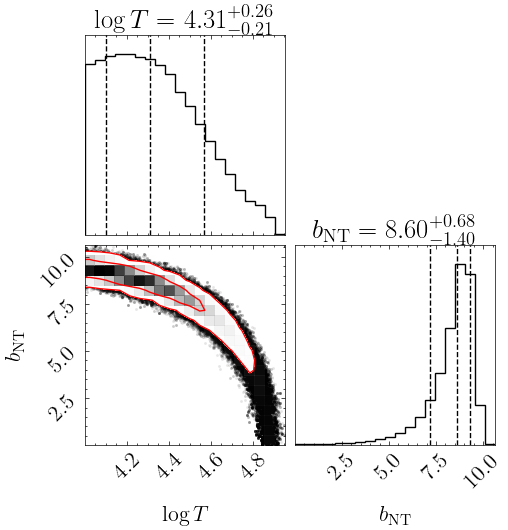

In [246]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [247]:
np.percentile(flat_samples['logT'], 100*cdf_3sig)

4.895021713991598

# DRAFT

## z=0.72

In [69]:
b_list = [[['HI', 'H', 25.6, 0.4],
          ['CIII', 'C', 15, 4],
          ['OIII', 'O', 12, 2]]]

In [70]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(200, 2)
nwalkers, ndim = pos.shape

In [71]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [72]:
sampler.run_mcmc(pos, 5000, progress=True)

100%|██████████████████████████████████████| 5000/5000 [00:13<00:00, 378.65it/s]


State([[ 4.5384403   8.09929585]
 [ 4.47312911 12.56506458]
 [ 4.51935019  9.9915456 ]
 [ 4.43163142 15.65060414]
 [ 4.52375086  9.37540148]
 [ 4.54954478  6.62458899]
 [ 4.52685679 10.13970275]
 [ 4.42873199 14.08212653]
 [ 4.50605638 12.29829318]
 [ 4.50825934 10.95642096]
 [ 4.52653629 10.0437353 ]
 [ 4.43088461 14.06331714]
 [ 4.52991303 10.05491318]
 [ 4.5366154   8.2728032 ]
 [ 4.57220497  8.25733952]
 [ 4.47898707 12.46445221]
 [ 4.57009848  8.66609242]
 [ 4.50306259 11.53717785]
 [ 4.36597978 15.86877089]
 [ 4.56793488  9.68422604]
 [ 4.45187513 13.86462879]
 [ 4.56351901  5.3446461 ]
 [ 4.59466794  3.46409942]
 [ 4.53785633  9.65510504]
 [ 4.55211141  8.05027689]
 [ 4.49100075 11.93868292]
 [ 4.54138785 10.3322841 ]
 [ 4.54959999  9.2107803 ]
 [ 4.42833962 14.57471485]
 [ 4.51295023 12.04145711]
 [ 4.59385652  7.83400509]
 [ 4.46092935 12.78548227]
 [ 4.5263072  12.37414796]
 [ 4.48133168 13.77105522]
 [ 4.49751563 10.66109777]
 [ 4.53237196  9.36835803]
 [ 4.53007861 10.24665

In [73]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=500, flat=True), 
                                columns=['logT', 'b_NT'])

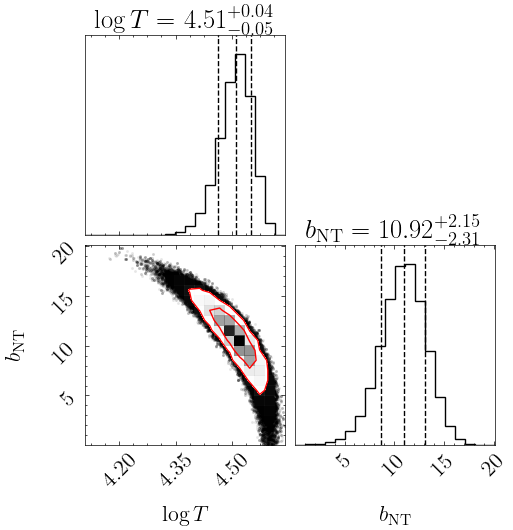

In [74]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [75]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

12.821218751413966

In [76]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

12.567972555170432

In [77]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

12.375375197197565

In [78]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

12.088713599866455

In [79]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

11.898696060874855

In [80]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

11.805498059645785

In [81]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

11.77212289470581

In [82]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

11.670068905881259

In [83]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

11.358898777000608